## Incorporating Automatic Differentiation in `Tidy3D`

With that basic introduction to automatic differentiation using `autograd`, we can now show how `Tidy3D` lets us do the same thing but where our functions can now involve setting up, running, and postprocessing a `tidy3d.Simulation`.

In [1]:
import os
import numpy as np
import tidy3d as td
import tidy3d.web as web
import matplotlib.pyplot as plt
import autograd.numpy as anp
import autograd as ag
from tidy3d.web.core.environment import Env, dev, prod

Env.set_current(prod)
web.configure("DmdQlSo1GtT9Q0KdynZGqZBx0TPyp6tEgwd6GeAGY1aooJCY")

td.config.logging_level = "INFO"

Configured successfully.


# Transformed Geometry

In [2]:
def make_simulation(center: tuple, size: tuple, scale: tuple, translate: tuple, eps: float) -> td.Simulation:
    """Makes a simulation with a variable scatter width, height, and relative permittivity."""

    wavelength = 1.0
    freq0 = td.C_0 / wavelength
    dl = 0.02

    # Static structure
    waveguide = td.Structure(
        geometry=td.Box(size=(td.inf, 0.3, 0.2)), medium=td.Medium(permittivity=2.0)
    )

    # Forward source
    mode_src = td.ModeSource(
        size=(0, 1.5, 1.5),
        center=(-0.9, 0, 0),
        mode_index=0,
        source_time=td.GaussianPulse(freq0=freq0, fwidth=freq0 / 10),
        direction="+",
    )

    # Monitor
    mode_mnt = td.ModeMonitor(
        size=(0, 1.5, 1.5),
        center=(+0.9, 0, 0),
        mode_spec=mode_src.mode_spec,
        freqs=[freq0],
        name="mode",
    )

    # Geometry and transformation
    base_geometry = td.Box(center=center, size=size)
    transformed_geometry = base_geometry#.scaled(x=scale[0], y=scale[1], z=scale[2]).translated(x=translate[0], y = translate[1], z = translate[2])

    # Scatterer structure
    scatterer = td.Structure(
        geometry=transformed_geometry,
        medium=td.Medium(permittivity=eps),
    )

    # Simulation setup
    return td.Simulation(
        size=(2, 2, 2),
        run_time=1e-12,
        structures=[ waveguide, scatterer],
        sources=[mode_src],
        monitors=[mode_mnt],
        boundary_spec=td.BoundarySpec.all_sides(td.PML()),
        grid_spec=td.GridSpec.uniform(dl=dl),
    )


# Scaled Box


Let's try setting up the simulation and plotting it for starters.

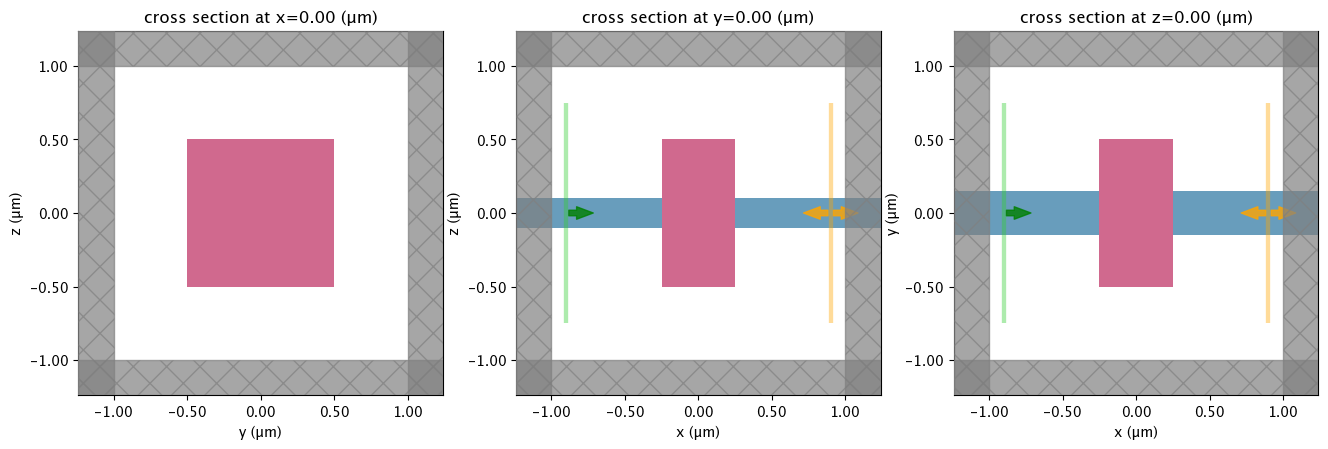

In [3]:
# starting set of input parameters
center0 = (0.0, 0.0, 0.0)
size0 = (0.5, 1.0, 1.0) 
scale0 = anp.array([1.2, 1.3, 1.4])
translate0  = anp.array([0.1, 0.2, 0.3])
eps0 = 3.0

sim = make_simulation(center=center0, size=size0, scale = scale0, translate = translate0,  eps=eps0)
_, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, dim in zip(axes, "xyz"):
    sim.plot(**{dim: 0}, ax=ax)
plt.show()

### Post-processing the output data

After the simulation is run, it returns a `td.SimulationData` containing the data we want to post-process.

Let's write a function that will process this `td.SimulationData` and return the power in the mode amplitude of our output mode monitor.

In [4]:
def compute_power(sim_data: td.SimulationData) -> float:
    """Post process the result of the Simulation run to return the power in the mode at index=0."""

    freq0 = sim_data.simulation.monitors[0].freqs[0]
    mode_data = sim_data["mode"]
    mode_amps = mode_data.amps
    amp = mode_amps.sel(direction="+", f=freq0, mode_index=0).values
    return anp.sum(abs(amp) ** 2)

### Defining the tidy3d simulation function for differentiation

Next, we can import the `tidy3d..web.run` function and put all the pieces together into a single function to compute the 0th order transmitted power as a function of `center`, `size`, and `eps` (relative permittivty) of the scatterer.

In [5]:
def power(center, size, scale, translate, eps):
    """Compute power transmitted into 0th order mode given scatterer parameters."""
    sim = make_simulation(center=center, size=size, scale=scale,translate=translate, eps=eps)
    sim_data = web.run(sim, task_name="autograd_1", local_gradient=True)
    return compute_power(sim_data)

In [6]:
power(center0, size0, scale0, translate0, eps0)

12:57:55 EDT Created task 'autograd_1' with task_id                             
             'fdve-3cddb518-6ac2-4823-9c4e-02b741536919' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=907367;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=882105;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\taskId]8;;\]8;id=907367;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\=]8;;\]8;id=592824;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\fdve]8;;\]8;id=907367;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\-3cddb518-6ac]8;;\
             ]8;id=907367;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\2-4823-9c4e-02b741536919']8;;\.

Output()

12:58:01 EDT Maximum FlexCredit cost: 0.025. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

             status = queued

...

12:58:27 EDT status = success

12:58:28 EDT View simulation result at                                          
             ]8;id=681462;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=583905;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\taskId]8;;\]8;id=681462;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\=]8;;\]8;id=877038;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\fdve]8;;\]8;id=681462;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\-3cddb518-6ac]8;;\
             ]8;id=681462;https://tidy3d.simulation.cloud/workbench?taskId=fdve-3cddb518-6ac2-4823-9c4e-02b741536919\2-4823-9c4e-02b741536919']8;;\.

Output()

             loading simulation from simulation_data.hdf5

0.5520314285799753

### Running and differentiating the simulation using `autograd`

Finally, using the `autograd` tools described earlier, we can differentiate this `power` function. 

For demonstration, let's use `autograd.value_and_grad` to both compute the power **and** the gradient w.r.t. each of the 3 input parameters.

In [7]:
d_power = ag.value_and_grad(power, argnum=(0, 1, 2, 3, 4))

We will run this function and assign variables to the power values and the gradients returned.

Note that running this will set off **two** separate tasks, one after another, called, `"adjoint_power_fwd"` and `"adjoint_power_adj"`.

The first is evaluating our simulation in "forward mode", computing the power and stashing information needed for gradient computation.

The second step runs the "adjoint" simulation, in which the output monitor is converted to a source and the simulation is re-run.

The results of both of these simulations runs are combined behind the scene to tell `autograd` how to compute the gradient for us.

In [8]:
power_value, (dp_dcenter, dp_dsize, dp_dscale, dp_dtranslate, dp_deps) = d_power(center0, size0, scale0, translate0, eps0)

12:58:29 EDT INFO: running primitive '_run_primitive()'

             INFO: running tidy3d_autograd simulation with '_run_tidy3d()'

             Created task 'autograd_1' with task_id                             
             'fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=244359;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=210636;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca\taskId]8;;\]8;id=244359;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca\=]8;;\]8;id=170269;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca\fdve]8;;\]8;id=244359;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca\-19f4e0d0-aec]8;;\
             ]8;id=244359;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19f4e0d0-aece-4f5d-997c-09745a09d0ca\e-4f5d-997c-09745a09d0ca']8;;\.

Output()

...

Output()

12:59:42 EDT status = success

             View simulation result at                                          
             ]8;id=584178;https://tidy3d.simulation.cloud/workbench?taskId=fdve-779b8d5c-935d-448f-8c14-667aa921949d\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=500444;https://tidy3d.simulation.cloud/workbench?taskId=fdve-779b8d5c-935d-448f-8c14-667aa921949d\taskId]8;;\]8;id=584178;https://tidy3d.simulation.cloud/workbench?taskId=fdve-779b8d5c-935d-448f-8c14-667aa921949d\=]8;;\]8;id=934054;https://tidy3d.simulation.cloud/workbench?taskId=fdve-779b8d5c-935d-448f-8c14-667aa921949d\fdve]8;;\]8;id=584178;https://tidy3d.simulation.cloud/workbench?taskId=fdve-779b8d5c-935d-448f-8c14-667aa921949d\-779b8d5c-935]8;;\
             ]8;id=584178;https://tidy3d.simulation.cloud/workbench?taskId=fdve-779b8d5c-935d-448f-8c14-667aa921949d\d-448f-8c14-667aa921949d']8;;\.

Output()

12:59:45 EDT loading simulation from simulation_data_adjoint.hdf5

> Note: the gradient evaluation functions returned by `autograd.grad()` do not accept keyword arguments (ie. `center=(0.,0.,0.)`) and instead accept positional arguments (without the argument name). You may run across this when trying to evaluate gradients so it's a good idea to keep in mind.

We can take a look at our computed power and gradient information. 

In [9]:
print(f"power = {power_value:.5f}")
print(f"d_power/d_center = {dp_dcenter}")
print(f"d_power/d_size = {dp_dsize}")
print(f"d_power/d_scale = {dp_dscale}")
print(f"d_power/d_translate = {dp_dtranslate}")
print(f"d_power/d_eps = {dp_deps}")

power = 0.55203
d_power/d_center = (array(0.00797734), array(1.66337445e-05), array(-0.00055557))
d_power/d_size = (array(-0.0669728), array(0.12843257), array(-0.13609388))
d_power/d_scale = [0. 0. 0.]
d_power/d_translate = [0. 0. 0.]
d_power/d_eps = -0.16138198667344789


In [11]:
def finite_diff_size_x(power_fn, center, size, scale, translate, eps, delta=1e-3):
    """
    Finite-difference check for d(power)/d(size_x).
    """

    size_arr = np.array(size)

    # +delta on x-component
    size_plus = size_arr.copy()
    size_plus[0] += delta
    p_plus = power_fn(center, tuple(size_plus), scale, translate, eps)

    # -delta on x-component
    size_minus = size_arr.copy()
    size_minus[0] -= delta
    p_minus = power_fn(center, tuple(size_minus), scale, translate, eps)

    # Central-difference derivative
    grad_size_x = (p_plus - p_minus) / (2.0 * delta)

    print(f"Power at size_x + {delta}:        {p_plus:.5f}")
    print(f"Power at size_x - {delta}:        {p_minus:.5f}")
    print(f"Finite-difference derivative wrt size_x = {grad_size_x:.5f}")

    return grad_size_x



grad_x = finite_diff_size_x(
    power, 
    center0,
    size0,
    scale0,
    translate0,
    eps0,
    delta=1e-3
)



13:02:15 EDT Created task 'autograd_1' with task_id                             
             'fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2' and task_type 'FDTD'.

             View task using web UI at                                          
             ]8;id=320376;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=505229;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2\taskId]8;;\]8;id=320376;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2\=]8;;\]8;id=962028;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2\fdve]8;;\]8;id=320376;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2\-d83ff66f-443]8;;\
             ]8;id=320376;https://tidy3d.simulation.cloud/workbench?taskId=fdve-d83ff66f-4438-4399-9c73-e8f15ac4f0e2\8-4399-9c73-e8f15ac4f0e2']8;;\.

Output()

13:02:22 EDT Maximum FlexCredit cost: 0.025. Minimum cost depends on task       
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

13:02:23 EDT status = queued

...

13:03:32 EDT status = success

             View simulation result at                                          
             ]8;id=891724;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19c80a2d-1cb1-4bf9-8d8a-f29082e35a19\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=250531;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19c80a2d-1cb1-4bf9-8d8a-f29082e35a19\taskId]8;;\]8;id=891724;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19c80a2d-1cb1-4bf9-8d8a-f29082e35a19\=]8;;\]8;id=580710;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19c80a2d-1cb1-4bf9-8d8a-f29082e35a19\fdve]8;;\]8;id=891724;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19c80a2d-1cb1-4bf9-8d8a-f29082e35a19\-19c80a2d-1cb]8;;\
             ]8;id=891724;https://tidy3d.simulation.cloud/workbench?taskId=fdve-19c80a2d-1cb1-4bf9-8d8a-f29082e35a19\1-4bf9-8d8a-f29082e35a19']8;;\.

Output()

13:03:33 EDT loading simulation from simulation_data.hdf5

Power at size_x + 0.001:        0.55082
Power at size_x - 0.001:        0.55330
Finite-difference derivative wrt size_x = -1.24233


From this, we can infer several things that fit our intuition, for example that:
* the transmitted power should **decrease** if we increase the permittivity of our scatterer.
* the transmitted power does not depend strongly on the position of the scatterer along the propagation direction.

## Conclusion & Next Steps

This gives the most basic introduction to the principles behind the adjoint plugin.

In subsequent notebooks, we will show how to:
 * Check the gradients returned by this method against brute force computed gradients for accuracy.
 * Perform gradient-based optimization using the adjoint plugin.